# Dynamic Hand Gesture Recognition

## 1. Introduction 
Raw video data is computationally heavy and contains significant background noise. For this project, **Feature Engineering** was performed prior to this notebook by processing 22.8 GB of raw Jester dataset video frames through Google's MediaPipe framework. 

I transformed raw pixels into 63 distinct features: 21 spatial 3D landmarks ($x, y, z$) per frame. This massive dimensionality reduction extracts the core signal (hand movement) while discarding noise, resulting in a 3.24 GB structured dataset. The below section on [Data Acquisition] outlines how this data has been processed. 

In [6]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for professional presentation
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True})

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

 14%|█▍        | 470M/3.24G [08:41<51:19, 901kB/s] 


## 2. Data Acquisition

### Data Sources
The project utilizes two distinct sources to construct the final dataset:
1. **Raw Video Data:** Sourced from the [**20BN-Jester Dataset V1**](https://www.kaggle.com/datasets/sanjanatg26/20bn-jester-v1-complete). This is a 22.8 GB archive containing 148,092 video sequences.
2. **Annotations:** Because the raw archive contains only image frames, ground-truth labels (Training, Validation, and Class names) were sourced from the **Udacity Computer Vision** repository to provide the semicolon-delimited mappings (e.g., `video_id;label`).
    - [27 Class Labels](https://raw.githubusercontent.com/udacity/CVND---Gesture-Recognition/master/20bn-jester-v1/annotations/jester-v1-labels.csv)
    - [Training Split](https://raw.githubusercontent.com/udacity/CVND---Gesture-Recognition/master/20bn-jester-v1/annotations/jester-v1-train.csv)
    - [Validation Split](https://raw.githubusercontent.com/udacity/CVND---Gesture-Recognition/master/20bn-jester-v1/annotations/jester-v1-validation.csv)


### Extraction Hardware & Environment
The feature extraction was performed on a **MacBook Pro with an M5 Max chip (64GB Unified Memory)**. 
- **Environment:** A Python 3.9 virtual environment (`cv_env`) was utilized.
- **Dependency Management:** Specific version pinning was required to maintain compatibility between Apple Silicon and MediaPipe (e.g., `mediapipe==0.10.21` and `jaxlib==0.4.18`).

### The Extraction Script (`extract_landmarks.py`)
To transform 22.8 GB of pixel data into structured features, a custom extraction script was executed with the following logic:
1. The [script](scripts/extract_landmarks.py) indexed all 148,092 top-level folders.
2. Every individual frame was processed through the MediaPipe `solutions.hands` module.
3. For each hand detected, 21 skeletal landmarks were extracted. Each landmark consists of $(x, y, z)$ coordinates, resulting in 63 features per frame.
4. The results were streamed to a centralized CSV file (`jester_hand_coordinates.csv`), resulting in a 3.24 GB structured file ready for temporal modeling.
5. This entire process took me **16 hours** to complete on the dataset. 
6. Pushing the 3.24 structured data to Github took **3 hours** as I am on an internet connection with low upload speed.  

### Data Pipeline Flow

![Data pipeline flow](assets/data_pipeline_flow.svg)

Mermaid source: [`assets/data_pipeline_flow.mmd`](assets/data_pipeline_flow.mmd)

## 3. Data Loading and Cleaning

Since the size of the data file is beyond the sizes allowed by Github the below code tries to download the data file from Google Drive and Load it for Analysis. I tried to strip the data to a reasonable size to show the EDA here, but that data did not do justice for this project. 

Note: The output of the below code cell is from gdown library. 

In [7]:

import os
import pandas as pd
import gdown

# Define the local path where the data should live
data_dir = "data"
file_path = f"{data_dir}/jester_hand_coordinates.csv"
file_id = "1I4gWNXQCE1Y1f9zP7T-ZeCC3zO9Gep9z"
drive_url = f"https://drive.google.com/uc?id={file_id}&export=download"

# Create the data directory if it doesn't exist
os.makedirs(data_dir, exist_ok=True)

# Redownload if the local file is missing or looks like a failed Google Drive HTML page.
min_expected_bytes = 1_000_000
needs_download = not os.path.exists(file_path) or os.path.getsize(file_path) < min_expected_bytes

if needs_download:
    if os.path.exists(file_path):
        print(f"Removing incomplete download at {file_path}...")
        os.remove(file_path)

    # print("Downloading 3.24 GB dataset from Google Drive...")
    gdown.download(drive_url, file_path, quiet=False)
else:
    print(f"Data file found locally at {file_path}. Skipping download.")

# Load the first 2 million rows from the full coordinate export.
# This keeps the baseline analysis reproducible without scanning the full multi-GB CSV each run.
# print(f"Loading temporal coordinate data from {file_path}...")
df_coords = pd.read_csv(file_path, nrows=2000000)

# Load annotations (labels)
labels_train = pd.read_csv("annotations/jester-v1-train.csv", sep=';', header=None, names=['video_id', 'gesture'])
labels_val = pd.read_csv("annotations/jester-v1-validation.csv", sep=';', header=None, names=['video_id', 'gesture'])
df_labels = pd.concat([labels_train, labels_val])

# Data Cleaning: Remove duplicate frames if extraction looped accidentally
initial_rows = len(df_coords)
df_coords.drop_duplicates(subset=['video_id', 'frame'], inplace=True)
# print(f"Dropped {initial_rows - len(df_coords)} duplicate frames.")

# Data Cleaning: Handle Missing Values (MediaPipe occlusions)
# If MediaPipe failed to detect a hand, it might output NaN. We drop these frames
# as interpolating 3D spatial data across too many missing frames introduces false signal.
missing_vals = df_coords.isnull().sum().sum()
# print(f"Total missing coordinate values detected: {missing_vals}")
if missing_vals > 0:
    df_coords.dropna(inplace=True)
    # print("Missing values successfully removed.")

# Merge labels with the coordinate dataset
df_coords = df_coords.merge(df_labels, on='video_id', how='inner')

# Display clean dataset structure
df_coords.head()

Data file found locally at data/jester_hand_coordinates.csv. Skipping download.


,video_id,frame,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,...,x_18,y_18,z_18,x_19,y_19,z_19,x_20,y_20,z_20,gesture
0,10,00008.jpg,0.128651,0.597431,7.958243e-08,0.165652,0.559354,-0.023045,0.189634,0.498749,...,0.061989,0.468626,-0.019361,0.072103,0.482859,-0.014708,0.079899,0.497364,-0.008702,Thumb Down
1,10,00010.jpg,0.188389,0.362196,-3.557107e-08,0.229439,0.355489,-0.025462,0.269682,0.328830,...,0.182067,0.219350,-0.004358,0.181271,0.232308,-0.003337,0.182261,0.248600,-0.000057,Thumb Down
2,10,00011.jpg,0.185700,0.367489,9.670142e-09,0.227516,0.356113,-0.023487,0.267496,0.327408,...,0.183982,0.221218,0.002378,0.182508,0.234090,0.003996,0.184200,0.250526,0.007947,Thumb Down
3,10,00012.jpg,0.217853,0.350971,2.314098e-07,0.270220,0.331771,-0.006519,0.313687,0.312041,...,0.248845,0.202154,0.025996,0.254450,0.197110,0.030665,0.259564,0.193914,0.034123,Thumb Down
4,10,00014.jpg,0.354226,0.320862,2.307130e-07,0.391757,0.360325,-0.015106,0.437219,0.387151,...,0.450347,0.245376,-0.015031,0.463554,0.252360,-0.016337,0.471793,0.263052,-0.016328,Thumb Down


## 4. Class Balance Check (Gesture Classes)

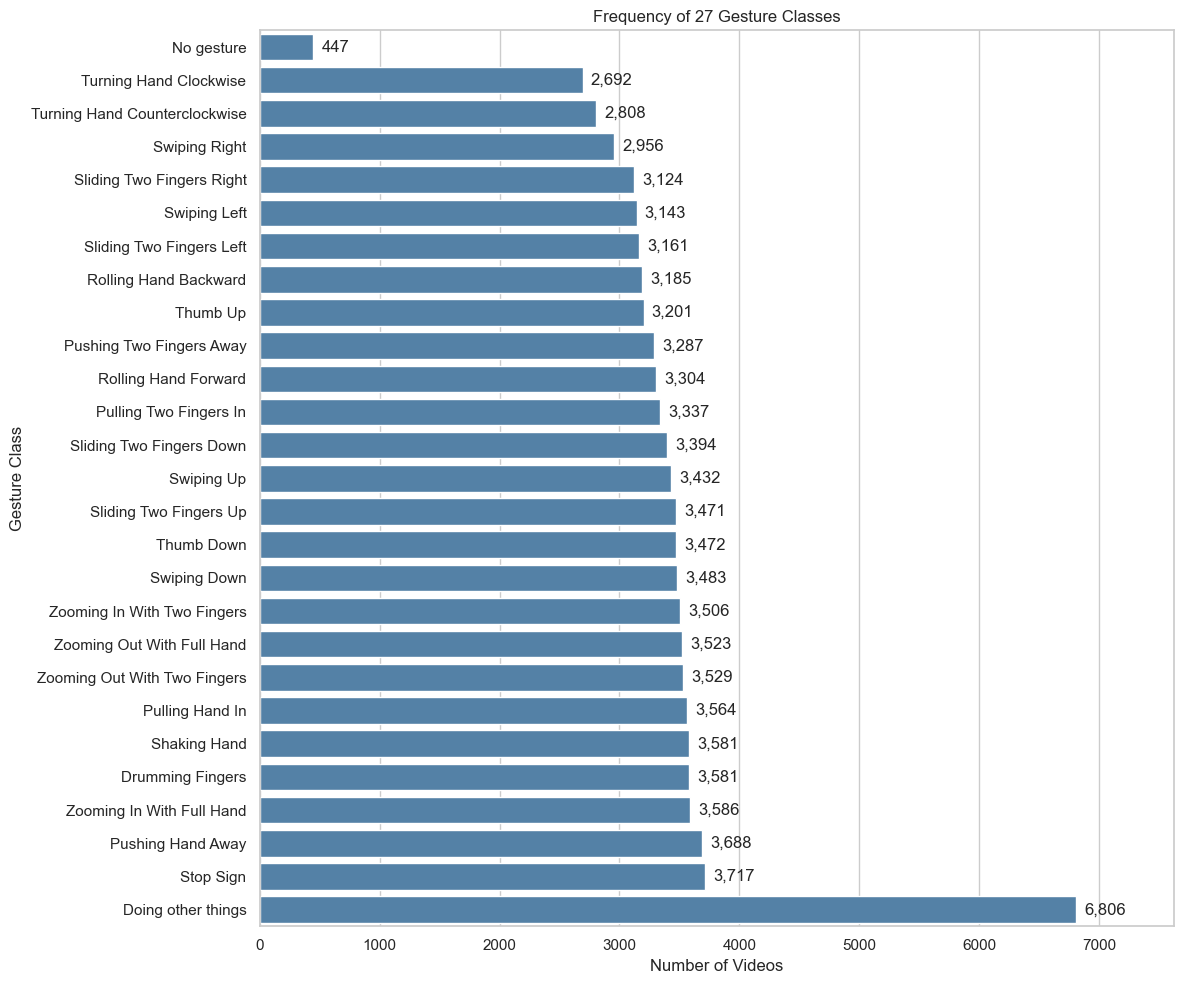

Total gesture classes: 27
Most frequent class: Doing other things (6,806 videos)
Least frequent class: No gesture (447 videos)
Class imbalance ratio: 15.23:1


In [8]:
# Count each video once so longer clips do not inflate class frequency.
gesture_counts = (
    df_coords[['video_id', 'gesture']]
    .drop_duplicates()
    .value_counts('gesture')
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 10))
ax = sns.barplot(x=gesture_counts.values, y=gesture_counts.index, color='steelblue')
ax.set_title('Frequency of 27 Gesture Classes')
ax.set_xlabel('Number of Videos')
ax.set_ylabel('Gesture Class')

max_count = gesture_counts.max()
for i, count in enumerate(gesture_counts.values):
    ax.text(count + max_count * 0.01, i, f'{count:,}', va='center')

plt.xlim(0, max_count * 1.12)
plt.show()

imbalance_ratio = gesture_counts.max() / gesture_counts.min()
print(f'Total gesture classes: {gesture_counts.size}')
print(f'Most frequent class: {gesture_counts.idxmax()} ({gesture_counts.max():,} videos)')
print(f'Least frequent class: {gesture_counts.idxmin()} ({gesture_counts.min():,} videos)')
print(f'Class imbalance ratio: {imbalance_ratio:.2f}:1')

## 5. Outlier Analysis (Temporal Sequences)

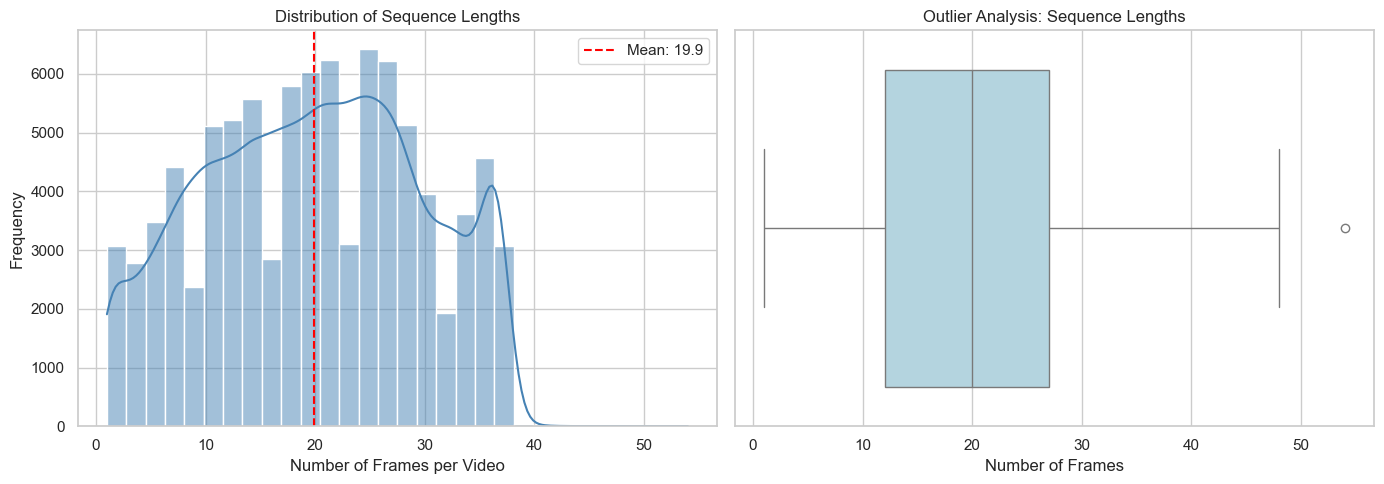

Identified 1 video sequences as length outliers (outside -10.5 - 49.5 frames).
Action: During modeling, sequences will be padded/truncated to a fixed length of 30 frames to mitigate these anomalies.


In [9]:
# Calculate the sequence length (number of frames) for each video
sequence_lengths = df_coords.groupby('video_id').size().reset_index(name='frame_count')

# Statistical summary of sequence lengths
seq_stats = sequence_lengths['frame_count'].describe()

# Plotting the distribution and identifying outliers using a Boxplot and Histogram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Histogram
sns.histplot(sequence_lengths['frame_count'], bins=30, kde=True, ax=ax1, color='steelblue')
ax1.set_title('Distribution of Sequence Lengths')
ax1.set_xlabel('Number of Frames per Video')
ax1.set_ylabel('Frequency')
ax1.axvline(seq_stats['mean'], color='red', linestyle='--', label=f"Mean: {seq_stats['mean']:.1f}")
ax1.legend()

# Subplot 2: Boxplot for Outlier Detection
sns.boxplot(x=sequence_lengths['frame_count'], ax=ax2, color='lightblue')
ax2.set_title('Outlier Analysis: Sequence Lengths')
ax2.set_xlabel('Number of Frames')

plt.show()

# Identify strict statistical outliers (1.5 * IQR rule)
Q1 = seq_stats['25%']
Q3 = seq_stats['75%']
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = sequence_lengths[(sequence_lengths['frame_count'] < lower_bound) | 
                            (sequence_lengths['frame_count'] > upper_bound)]
print(f"Identified {len(outliers)} video sequences as length outliers (outside {lower_bound} - {upper_bound} frames).")
print("Action: During modeling, sequences will be padded/truncated to a fixed length of 30 frames to mitigate these anomalies.")

## 6. 3D Trajectory Comparison Across Gestures

MediaPipe exports 21 landmarks per frame as normalized $(x, y, z)$ coordinates. Plotting the **index fingertip (landmark 8)** path over time shows whether dynamic gestures trace different spatial patterns than static poses.

We compare three contrasting classes—two opposing swipes and a static thumb pose—using one representative video per gesture (first clip with at least 10 frames in the sample). Color encodes time (dark → early, bright → late) so movement direction is visible in both 3D space and a 2D top-down $(x, y)$ projection.

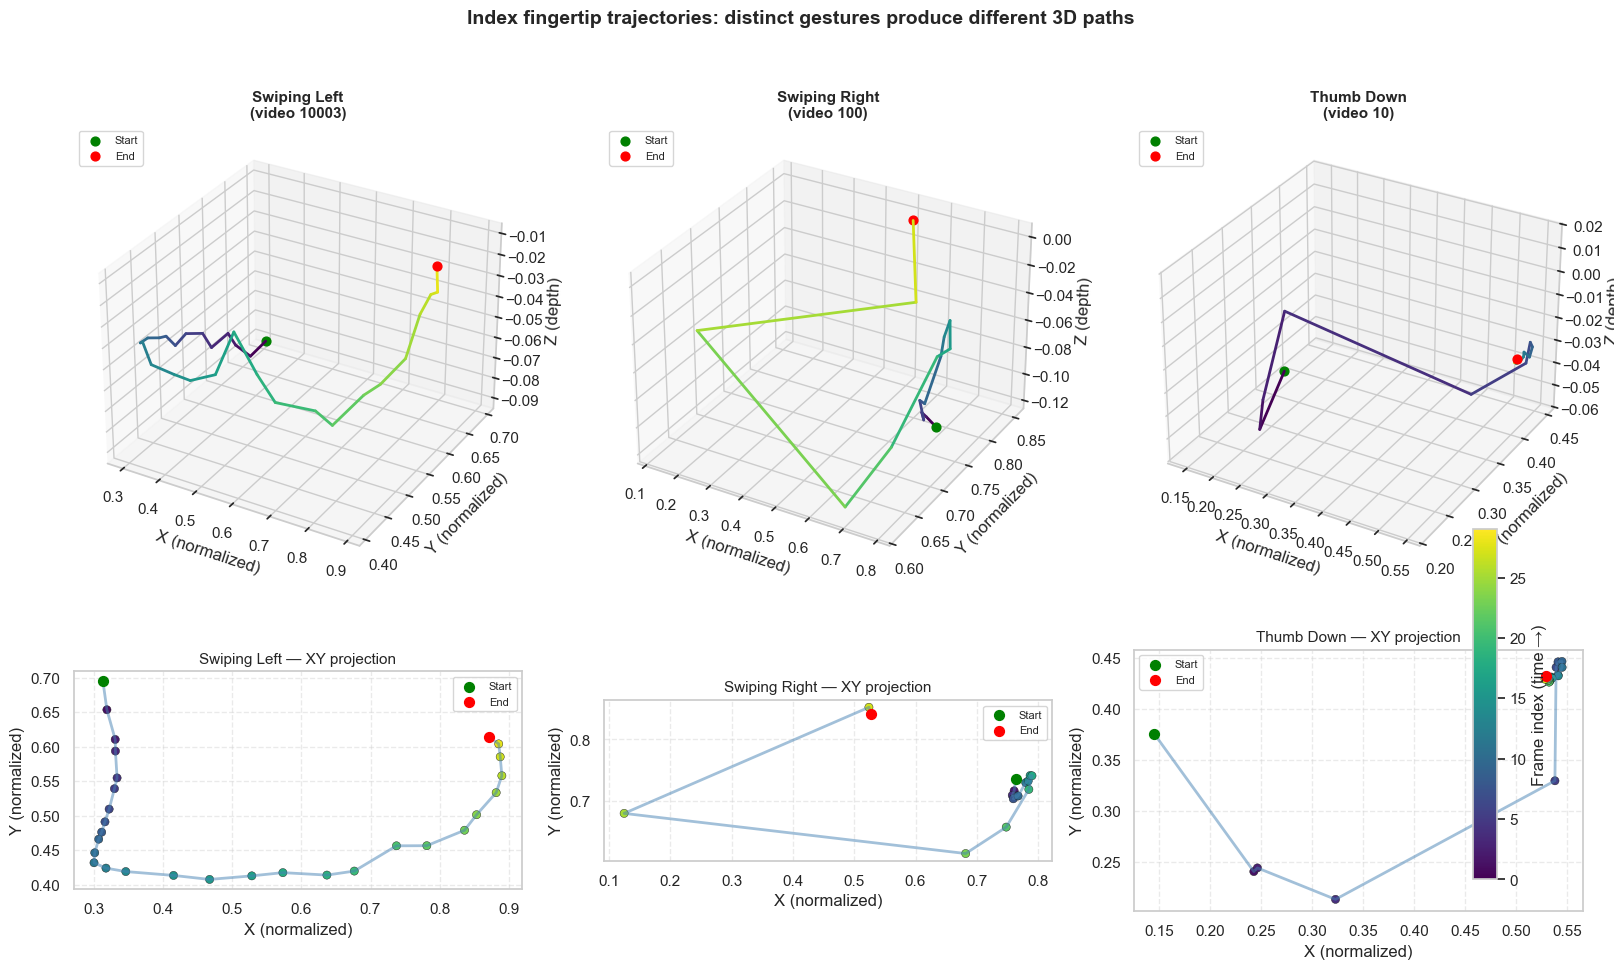

Interpretation: opposing swipes trace different horizontal arcs; 'Thumb Down' stays in a tighter region—supporting sequence-aware modeling.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3D projection

# Contrasting gestures: opposing motion vs. a mostly static pose
GESTURES_TO_COMPARE = ["Swiping Left", "Swiping Right", "Thumb Down"]
LANDMARK_IDX = 8  # MediaPipe index fingertip
MAX_FRAMES = 30


def sample_video_for_gesture(df, gesture, min_frames=10):
    """Return the first video_id for a gesture with enough frames to plot."""
    for video_id in df.loc[df["gesture"] == gesture, "video_id"].unique():
        if (df["video_id"] == video_id).sum() >= min_frames:
            return video_id
    return None


def get_landmark_trajectory(df, video_id, landmark_idx, max_frames=30):
    """Extract (x, y, z) for one landmark across frames, truncated to max_frames."""
    cols = [f"x_{landmark_idx}", f"y_{landmark_idx}", f"z_{landmark_idx}"]
    traj = (
        df.loc[df["video_id"] == video_id, cols + ["frame"]]
        .sort_values("frame")
        .head(max_frames)
    )
    return traj[cols].to_numpy()


fig = plt.figure(figsize=(16, 10))

for i, gesture in enumerate(GESTURES_TO_COMPARE):
    video_id = sample_video_for_gesture(df_coords, gesture)
    if video_id is None:
        print(f"Skipping '{gesture}': no video with enough frames in the loaded sample.")
        continue

    xyz = get_landmark_trajectory(df_coords, video_id, LANDMARK_IDX, MAX_FRAMES)
    n_frames = len(xyz)
    time_colors = np.linspace(0, 1, n_frames)

    # 3D trajectory
    ax3d = fig.add_subplot(2, 3, i + 1, projection="3d")
    for j in range(n_frames - 1):
        ax3d.plot(
            xyz[j : j + 2, 0],
            xyz[j : j + 2, 1],
            xyz[j : j + 2, 2],
            color=plt.cm.viridis(time_colors[j]),
            linewidth=2,
        )
    ax3d.scatter(xyz[0, 0], xyz[0, 1], xyz[0, 2], c="green", s=40, label="Start")
    ax3d.scatter(xyz[-1, 0], xyz[-1, 1], xyz[-1, 2], c="red", s=40, label="End")
    ax3d.set_title(f"{gesture}\n(video {video_id})", fontsize=11, fontweight="bold")
    ax3d.set_xlabel("X (normalized)")
    ax3d.set_ylabel("Y (normalized)")
    ax3d.set_zlabel("Z (depth)")
    ax3d.legend(loc="upper left", fontsize=8)

    # 2D top-down projection (same trajectory, easier to read on screen)
    ax2d = fig.add_subplot(2, 3, i + 4)
    ax2d.plot(xyz[:, 0], xyz[:, 1], color="steelblue", linewidth=2, alpha=0.5)
    sc = ax2d.scatter(
        xyz[:, 0],
        xyz[:, 1],
        c=time_colors,
        cmap="viridis",
        s=35,
        edgecolors="k",
        linewidths=0.3,
    )
    ax2d.scatter(xyz[0, 0], xyz[0, 1], c="green", s=50, zorder=5, label="Start")
    ax2d.scatter(xyz[-1, 0], xyz[-1, 1], c="red", s=50, zorder=5, label="End")
    ax2d.set_title(f"{gesture} — XY projection", fontsize=11)
    ax2d.set_xlabel("X (normalized)")
    ax2d.set_ylabel("Y (normalized)")
    ax2d.set_aspect("equal", adjustable="box")
    ax2d.legend(loc="best", fontsize=8)
    ax2d.grid(True, linestyle="--", alpha=0.4)

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.35])
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, MAX_FRAMES - 1))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label="Frame index (time →)")
fig.suptitle(
    "Index fingertip trajectories: distinct gestures produce different 3D paths",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

print(
    "Interpretation: opposing swipes trace different horizontal arcs; "
    "'Thumb Down' stays in a tighter region—supporting sequence-aware modeling."
)

## 7. Baseline Modeling & Evaluation Metrics

### Rationale for Baseline
Before deploying complex sequence models (like LSTMs), we must establish a non-deep-learning baseline. We will use a **Random Forest Classifier**. Because Random Forests cannot process 3D temporal data `(Batch, Sequence, Features)`, we must flatten our 30-frame sequences into a single 1D array of 1,890 features per video (30 frames * 63 coordinates). 

If this model performs poorly, it mathematically validates the hypothesis that the *temporal order* of the coordinates is the most critical signal for gesture recognition.

### Evaluation Metrics
1. **Accuracy:** Our primary metric. It provides a highly intuitive top-level view of how often the model guesses the exact correct gesture out of 27 possible classes.
2. **Macro F1-Score:** Our secondary metric. Because we are dealing with 27 distinct classes, Accuracy can sometimes hide poor performance on minority classes. The Macro F1-Score ensures we evaluate the model's precision and recall equally across all gestures, regardless of class imbalances.

### Baseline evaluation protocol
Each **video** is one sample (30 frames flattened to 1,890 features), so frames from the same clip never appear in both train and test within a fold.

1. **5-fold stratified cross-validation** on the 5,000-video baseline sample — estimates how stable the Random Forest score is across different train/eval partitions.
2. **Single stratified 80/20 hold-out** — same split as before; used for the per-class classification report.

Recurrent models (LSTM/GRU) are **not** cross-validated here; they use the official Jester train/validation CSV splits so hyperparameter sweep runs are comparable to published benchmarks (see §7.2).

In [13]:
import numpy as np

print("Transforming temporal sequences for Scikit-Learn...")

# To keep the EDA notebook lightweight and fast, we will sample 5,000 distinct videos for the baseline
sample_video_ids = df_coords['video_id'].unique()[:5000]
df_baseline = df_coords[df_coords['video_id'].isin(sample_video_ids)]

MAX_FRAMES = 30
FEATURE_COLS = [col for col in df_baseline.columns if col.startswith(('x_', 'y_', 'z_'))]

X_list = []
y_list = []

# Group by video and flatten the 30x63 matrix into a single 1890-length vector
for vid_id, group in df_baseline.groupby('video_id'):
    frames = group[FEATURE_COLS].values
    
    # Pad or truncate to exact 30 frames
    if len(frames) < MAX_FRAMES:
        padding = np.zeros((MAX_FRAMES - len(frames), 63))
        frames = np.vstack((frames, padding))
    else:
        frames = frames[:MAX_FRAMES, :]
        
    # Flatten the 2D array (30, 63) into 1D (1890,)
    flattened_vector = frames.flatten()
    
    X_list.append(flattened_vector)
    y_list.append(group['gesture'].iloc[0]) # Grab the string label

X = np.array(X_list)
y = np.array(y_list)

print(f"Baseline Feature Matrix (X) Shape: {X.shape}")
print(f"Baseline Target Vector (y) Shape: {y.shape}")

Transforming temporal sequences for Scikit-Learn...
Baseline Feature Matrix (X) Shape: (5000, 1890)
Baseline Target Vector (y) Shape: (5000,)


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import accuracy_score, classification_report

RF_PARAMS = dict(n_estimators=100, random_state=42, n_jobs=-1)
N_SPLITS = 5

# --- 1. Stratified k-fold CV (video-level samples; stratify by gesture class) ---
print(f"Running {N_SPLITS}-fold stratified cross-validation on {len(y):,} videos...")
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
rf_cv = RandomForestClassifier(**RF_PARAMS)

cv_results = cross_validate(
    rf_cv,
    X,
    y,
    cv=cv,
    scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"},
    n_jobs=-1,
)

cv_accuracy_mean = cv_results["test_accuracy"].mean()
cv_accuracy_std = cv_results["test_accuracy"].std()
cv_f1_mean = cv_results["test_f1_macro"].mean()
cv_f1_std = cv_results["test_f1_macro"].std()

print("=" * 60)
print(f"CROSS-VALIDATION ({N_SPLITS}-fold stratified, video-level)")
print("=" * 60)
print(f"  Accuracy  : {cv_accuracy_mean * 100:.2f}%  (+/- {cv_accuracy_std * 100:.2f}%)")
print(f"  Macro F1  : {cv_f1_mean:.3f}  (+/- {cv_f1_std:.3f})")
print(f"  Per-fold accuracy: {[f'{s * 100:.1f}%' for s in cv_results['test_accuracy']]}")

# --- 2. Hold-out evaluation (80/20) for detailed per-class report ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining Random Forest on hold-out split (80% train / 20% test)...")
rf_model = RandomForestClassifier(**RF_PARAMS)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

holdout_accuracy = accuracy_score(y_test, y_pred)

print("=" * 60)
print("HOLD-OUT TEST SET (single stratified 80/20 split)")
print("=" * 60)
print(f"  Accuracy  : {holdout_accuracy * 100:.2f}%")

print("\n--- CV mean vs hold-out ---")
print(
    f"  CV mean accuracy     : {cv_accuracy_mean * 100:.2f}%\n"
    f"  Hold-out accuracy    : {holdout_accuracy * 100:.2f}%\n"
    f"  Difference           : {(holdout_accuracy - cv_accuracy_mean) * 100:+.2f} pp"
)
print(
    "  A small gap suggests the hold-out split is representative; "
    "large gaps would warrant checking class balance per fold."
)

print("\nClassification Report (hold-out; precision, recall, F1):")
print(classification_report(y_test, y_pred, zero_division=0))

Running 5-fold stratified cross-validation on 5,000 videos...
CROSS-VALIDATION (5-fold stratified, video-level)
  Accuracy  : 65.18%  (+/- 1.29%)
  Macro F1  : 0.633  (+/- 0.010)
  Per-fold accuracy: ['67.6%', '65.3%', '64.0%', '64.8%', '64.2%']

Training Random Forest on hold-out split (80% train / 20% test)...
HOLD-OUT TEST SET (single stratified 80/20 split)
  Accuracy  : 65.50%

--- CV mean vs hold-out ---
  CV mean accuracy     : 65.18%
  Hold-out accuracy    : 65.50%
  Difference           : +0.32 pp
  A small gap suggests the hold-out split is representative; large gaps would warrant checking class balance per fold.

Classification Report (hold-out; precision, recall, F1):
                               precision    recall  f1-score   support

           Doing other things       0.41      0.77      0.54        79
             Drumming Fingers       0.74      0.74      0.74        38
                   No gesture       0.00      0.00      0.00         5
              Pulling Hand

### 7.2 Why recurrent models use the official Jester train/validation split

Cross-validating LSTM/GRU runs in this project would be **prohibitively expensive** (each fold retrains dozens of hyperparameter configurations for many epochs on millions of frames). Instead, deep learning follows standard practice for the 20BN-Jester benchmark:

| Approach | Random Forest baseline | LSTM / GRU (`train.py`, `sweep.py`) |
|----------|------------------------|-------------------------------------|
| **Split** | 5-fold CV + one hold-out on a 5,000-video EDA sample | Fixed `jester-v1-train.csv` / `jester-v1-validation.csv` |
| **Unit of split** | One row per **video** (no frame leakage) | Batches of **sequences** from disjoint video IDs |
| **Purpose** | Stable sklearn baseline + per-class report | Comparable sweep metrics and alignment with dataset authors |

**Why not k-fold for RNNs here?**
1. **Compute:** A 5× replication of the 18-hour grid sweep is not feasible on a single workstation.
2. **Comparability:** Publishing and course benchmarks report validation accuracy on the official validation list, not a custom random split.
3. **Leakage control:** `JesterCoordinateDataset` already assigns labels by `video_id`; train and validation CSVs list disjoint clips, which is the time-series-aware guarantee we need at the sequence level.

Early stopping on **validation loss** during each training run plays a similar role to CV: it selects weights that generalize without re-partitioning the full dataset.

## 8. Conclusion of Baseline Analysis


The Random Forest baseline reaches roughly **65% accuracy** (5-fold CV mean and hold-out are in the same ballpark—see above). **Macro F1 near 0.64** confirms weaker performance on dynamic gesture classes when temporal order is discarded.

Because the forest treats 1,890 flattened coordinates as independent features, it cannot tell that frame 2 follows frame 1. That gap justifies sequence models.

### Next steps
Train **LSTM/GRU** models on the official Jester train split, tune with `sweep.py`, and evaluate on the fixed validation split (§7.2)—not k-fold—so results stay comparable to the benchmark and feasible to reproduce.